In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")


In [20]:
df = pd.read_csv("KaggleV2-May-2016.csv")
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nHead:\n{df.head(3)}")


Shape: (110527, 14)

Dtypes:
PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object

Missing values:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

Head:
      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   

         AppointmentDay

In [21]:
# parse dates, build target, drop bad rows
df["ScheduledDay"]   = pd.to_datetime(df["ScheduledDay"]).dt.tz_localize(None)
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"]).dt.tz_localize(None)
df["no_show"] = (df["No-show"] == "Yes").astype(int)

print(f"Target distribution:\n{df['no_show'].value_counts()}")
print(f"No-show rate: {df['no_show'].mean():.1%}")

before = len(df)
df = df[(df["Age"] >= 0) & (df["Age"] <= 110)]
print(f"\nDropped {before - len(df)} rows with invalid age. Remaining: {len(df):,}")

df = df[df["AppointmentDay"] >= df["ScheduledDay"].dt.normalize()]
print(f"After removing negative wait times: {len(df):,} rows")


Target distribution:
no_show
0    88208
1    22319
Name: count, dtype: int64
No-show rate: 20.2%

Dropped 6 rows with invalid age. Remaining: 110,521
After removing negative wait times: 110,516 rows


In [22]:
# wait_days
df["wait_days"] = (df["AppointmentDay"] - df["ScheduledDay"].dt.normalize()).dt.days
print(f"Wait days summary:\n{df['wait_days'].describe().round(1)}")

# day of week
df["appt_day_of_week"] = df["AppointmentDay"].dt.dayofweek
dow_labels = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
df["appt_day_name"] = df["appt_day_of_week"].map(dow_labels)
print(f"\nAppointments by day of week:\n{df['appt_day_name'].value_counts()}")

# prior no-show rate per patient (no leakage: shift(1) before expanding window)
df = df.sort_values(["PatientId", "ScheduledDay"]).reset_index(drop=True)
df["_cn"] = df.groupby("PatientId")["no_show"].transform(lambda x: x.shift(1).expanding().sum())
df["_ca"] = df.groupby("PatientId")["no_show"].transform(lambda x: x.shift(1).expanding().count())
global_nsr = df["no_show"].mean()
df["prior_noshow_rate"] = (df["_cn"] / df["_ca"]).fillna(global_nsr)
df.drop(columns=["_cn", "_ca"], inplace=True)

print(f"\nPrior no-show rate summary:\n{df['prior_noshow_rate'].describe().round(3)}")
print(f"(First-visit rows filled with global rate: {global_nsr:.3f})")
print(f"\nFinal dataset: {df.shape[0]:,} rows | Engineered features: wait_days, appt_day_of_week, prior_noshow_rate")


Wait days summary:
count    110516.0
mean         10.2
std          15.3
min           0.0
25%           0.0
50%           4.0
75%          15.0
max         179.0
Name: wait_days, dtype: float64

Appointments by day of week:
appt_day_name
Wed    25866
Tue    25638
Mon    22711
Fri    19018
Thu    17244
Sat       39
Name: count, dtype: int64

Prior no-show rate summary:
count    110516.000
mean          0.214
std           0.242
min           0.000
25%           0.000
50%           0.202
75%           0.202
max           1.000
Name: prior_noshow_rate, dtype: float64
(First-visit rows filled with global rate: 0.202)

Final dataset: 110,516 rows | Engineered features: wait_days, appt_day_of_week, prior_noshow_rate


In [23]:
# buckets used by figures below
df["wait_bucket"] = pd.cut(df["wait_days"], bins=[-1, 0, 7, 30, 60, 999],
                            labels=["Same day", "1-7 days", "8-30 days", "31-60 days", "60+ days"])
df["age_bucket"] = pd.cut(df["Age"], bins=[0, 17, 34, 54, 74, 110],
                           labels=["0-17", "18-34", "35-54", "55-74", "75+"])

sms_nsr = df.groupby("SMS_received")["no_show"].mean()
print(f"No-show rate by SMS:\n{sms_nsr.rename({0: 'No SMS', 1: 'SMS Sent'}).round(3)}")


No-show rate by SMS:
SMS_received
No SMS      0.167
SMS Sent    0.276
Name: no_show, dtype: float64


In [24]:
feature_cols = [
    "wait_days", "appt_day_of_week", "prior_noshow_rate",
    "Age", "Gender", "SMS_received",
    "Scholarship", "Hipertension", "Diabetes", "Alcoholism", "Handcap",
]

model_df = df[feature_cols + ["no_show"]].copy()
model_df["Gender"] = (model_df["Gender"] == "M").astype(int)
model_df = model_df.dropna()
print(f"Modeling dataset: {model_df.shape[0]:,} rows × {len(feature_cols)} features")

X = model_df[feature_cols]
y = model_df["no_show"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


Modeling dataset: 110,516 rows × 11 features
Train: 88,412 | Test: 22,104


In [25]:
# logistic regression baseline
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

y_pred = lr.predict(X_test_s)
y_prob = lr.predict_proba(X_test_s)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
cv_scores = cross_val_score(lr, scaler.fit_transform(X), y, cv=5, scoring="roc_auc")

print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
print(f"ROC-AUC (test):      {roc_auc:.4f}")
print(f"ROC-AUC (5-fold CV): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

coef_df = pd.DataFrame({
    "feature":     feature_cols,
    "coefficient": lr.coef_[0],
}).sort_values("coefficient", key=abs, ascending=False)
print(f"\nCoefficients:\n{coef_df.to_string(index=False)}")


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.43      0.03      0.06      4462

    accuracy                           0.80     22104
   macro avg       0.62      0.51      0.47     22104
weighted avg       0.73      0.80      0.72     22104

ROC-AUC (test):      0.6677
ROC-AUC (5-fold CV): 0.6705 ± 0.0047

Coefficients:
          feature  coefficient
        wait_days     0.352931
prior_noshow_rate     0.239626
     SMS_received     0.173728
              Age    -0.168897
      Scholarship     0.060741
       Alcoholism     0.033686
 appt_day_of_week     0.023422
         Diabetes     0.022003
     Hipertension    -0.015400
          Handcap     0.005331
           Gender    -0.004172


In [26]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=50,
    class_weight="balanced", random_state=42, n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_prob)
rf_cv   = cross_val_score(rf, X, y, cv=5, scoring="roc_auc", n_jobs=-1)

print(f"Classification Report:\n{classification_report(y_test, rf_pred)}")
print(f"ROC-AUC (test):      {rf_auc:.4f}")
print(f"ROC-AUC (5-fold CV): {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")

rf_importance = pd.DataFrame({
    "feature":    feature_cols,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)
print(f"\nFeature Importances:\n{rf_importance.to_string(index=False)}")


/Users/alex/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/alex/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/alex/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/alex/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/alex/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires ver

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.53      0.67     17642
           1       0.31      0.83      0.45      4462

    accuracy                           0.59     22104
   macro avg       0.61      0.68      0.56     22104
weighted avg       0.80      0.59      0.63     22104

ROC-AUC (test):      0.7370
ROC-AUC (5-fold CV): 0.7408 ± 0.0054

Feature Importances:
          feature  importance
        wait_days    0.728889
prior_noshow_rate    0.086065
              Age    0.084650
     SMS_received    0.061657
 appt_day_of_week    0.014054
           Gender    0.007703
     Hipertension    0.007476
      Scholarship    0.004395
         Diabetes    0.002079
       Alcoholism    0.001740
          Handcap    0.001292


In [27]:
# GB doesn't take class_weight — use sample_weight instead
pos_weight     = (y_train == 0).sum() / (y_train == 1).sum()
sample_weights = np.where(y_train == 1, pos_weight, 1.0)

gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=50, random_state=42,
)
gb.fit(X_train, y_train, sample_weight=sample_weights)

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]
gb_auc  = roc_auc_score(y_test, gb_prob)
gb_cv   = cross_val_score(gb, X, y, cv=5, scoring="roc_auc", n_jobs=-1)

print(f"\nClassification Report:\n{classification_report(y_test, gb_pred)}")
print(f"ROC-AUC (test):      {gb_auc:.4f}")
print(f"ROC-AUC (5-fold CV): {gb_cv.mean():.4f} ± {gb_cv.std():.4f}")

gb_importance = pd.DataFrame({
    "feature":    feature_cols,
    "importance": gb.feature_importances_,
}).sort_values("importance", ascending=False)
print(f"\nFeature Importances:\n{gb_importance.to_string(index=False)}")


/Users/alex/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/alex/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.55      0.69     17642
           1       0.31      0.81      0.45      4462

    accuracy                           0.60     22104
   macro avg       0.62      0.68      0.57     22104
weighted avg       0.80      0.60      0.64     22104

ROC-AUC (test):      0.7412
ROC-AUC (5-fold CV): 0.7434 ± 0.0048

Feature Importances:
          feature  importance
        wait_days    0.755955
              Age    0.116350
prior_noshow_rate    0.082581
     SMS_received    0.012541
 appt_day_of_week    0.010564
           Gender    0.008069
      Scholarship    0.003598
       Alcoholism    0.003306
          Handcap    0.002869
     Hipertension    0.002602
         Diabetes    0.001566


In [28]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=512, shuffle=True)
pos_weight_nn = torch.tensor([pos_weight], dtype=torch.float32)


class NoShowNet(nn.Module):
    # 11 -> 64 -> 32 -> 1, ReLU + dropout
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),        nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),         nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)


model_nn = NoShowNet(input_dim=X_train_t.shape[1])
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)

# BCELoss doesn't take pos_weight — apply per-row weights manually
epochs = 30
train_losses = []
for epoch in range(epochs):
    model_nn.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model_nn(X_batch)
        weight = torch.where(y_batch == 1, pos_weight_nn, torch.ones_like(y_batch))
        loss = (weight * nn.functional.binary_cross_entropy(preds, y_batch, reduction="none")).mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.4f}")

model_nn.eval()
with torch.no_grad():
    nn_prob_t = model_nn(X_test_t).squeeze().numpy()

nn_pred = (nn_prob_t >= 0.5).astype(int)
nn_auc  = roc_auc_score(y_test, nn_prob_t)

print(f"\nClassification Report:\n{classification_report(y_test, nn_pred)}")
print(f"ROC-AUC (test): {nn_auc:.4f}")


Epoch 05/30 | Loss: 0.9871
Epoch 10/30 | Loss: 0.9650
Epoch 15/30 | Loss: 0.9557
Epoch 20/30 | Loss: 0.9490
Epoch 25/30 | Loss: 0.9459
Epoch 30/30 | Loss: 0.9452

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.49      0.64     17642
           1       0.30      0.85      0.44      4462

    accuracy                           0.56     22104
   macro avg       0.61      0.67      0.54     22104
weighted avg       0.80      0.56      0.60     22104

ROC-AUC (test): 0.7328


In [29]:
# 5-fold stratified CV for the NN — manual loop since PyTorch doesn't plug into cross_val_score
from sklearn.model_selection import StratifiedKFold

torch.manual_seed(42)
np.random.seed(42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
nn_cv_scores = []

X_arr = X.values if hasattr(X, "values") else X
y_arr = y.values if hasattr(y, "values") else y

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y_arr), start=1):
    X_tr_raw, X_val_raw = X_arr[train_idx], X_arr[val_idx]
    y_tr,     y_val     = y_arr[train_idx], y_arr[val_idx]

    # scale on training fold only
    fold_scaler = StandardScaler()
    X_tr  = fold_scaler.fit_transform(X_tr_raw)
    X_val = fold_scaler.transform(X_val_raw)

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32).unsqueeze(1)

    train_loader_cv = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=512, shuffle=True)

    fold_pos_weight = torch.tensor(
        [(y_tr == 0).sum() / (y_tr == 1).sum()], dtype=torch.float32
    )

    model_cv = NoShowNet(input_dim=X_tr_t.shape[1])
    optimizer_cv = torch.optim.Adam(model_cv.parameters(), lr=0.001)

    model_cv.train()
    for epoch in range(30):
        for X_batch, y_batch in train_loader_cv:
            optimizer_cv.zero_grad()
            preds = model_cv(X_batch)
            weight = torch.where(y_batch == 1, fold_pos_weight, torch.ones_like(y_batch))
            loss = (weight * nn.functional.binary_cross_entropy(preds, y_batch, reduction="none")).mean()
            loss.backward()
            optimizer_cv.step()

    model_cv.eval()
    with torch.no_grad():
        val_prob = model_cv(X_val_t).squeeze().numpy()
    fold_auc = roc_auc_score(y_val, val_prob)
    nn_cv_scores.append(fold_auc)
    print(f"Fold {fold_idx}/5  ROC-AUC: {fold_auc:.4f}")

nn_cv_mean = np.mean(nn_cv_scores)
nn_cv_std  = np.std(nn_cv_scores)
print(f"\nNeural Network 5-fold CV ROC-AUC: {nn_cv_mean:.4f} ± {nn_cv_std:.4f}")
print(f"Individual fold scores: {[round(s, 4) for s in nn_cv_scores]}")


Fold 1/5  ROC-AUC: 0.7386
Fold 2/5  ROC-AUC: 0.7422
Fold 3/5  ROC-AUC: 0.7425
Fold 4/5  ROC-AUC: 0.7308
Fold 5/5  ROC-AUC: 0.7373

Neural Network 5-fold CV ROC-AUC: 0.7383 ± 0.0043
Individual fold scores: [0.7386, 0.7422, 0.7425, 0.7308, 0.7373]


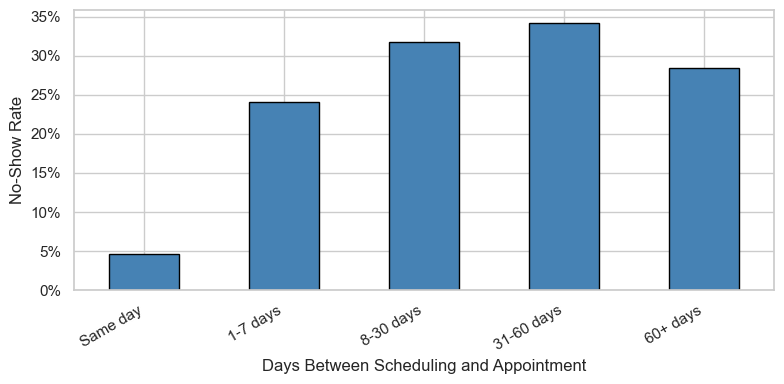

In [30]:
# Figure 1 — no-show rate by wait time
fig, ax = plt.subplots(figsize=(8, 4))
wait_nsr = df.groupby("wait_bucket", observed=True)["no_show"].mean()
wait_nsr.plot(kind="bar", ax=ax, edgecolor="black", color="steelblue")
ax.set_xlabel("Days Between Scheduling and Appointment")
ax.set_ylabel("No-Show Rate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("figure1.png", dpi=150, bbox_inches="tight")
plt.show()


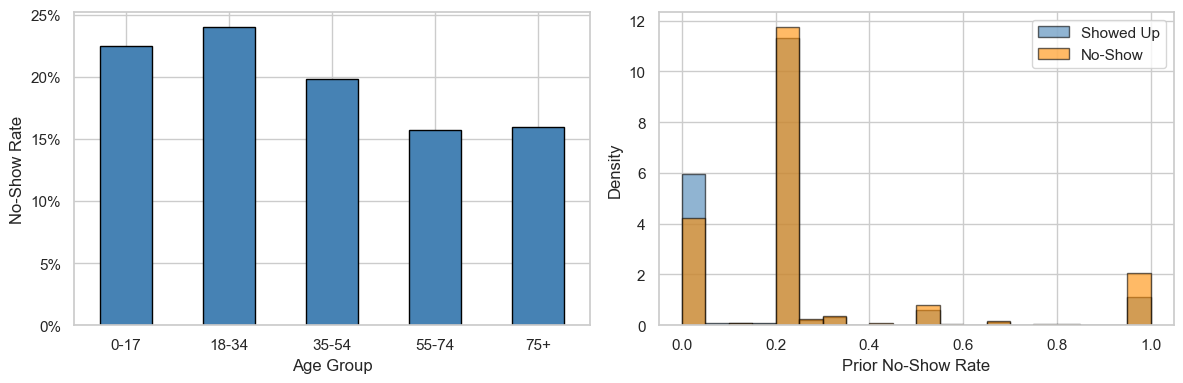

In [31]:
# Figure 2 — age group + prior no-show histogram
age_nsr = df.groupby("age_bucket", observed=True)["no_show"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: age group bar chart
age_nsr.plot(kind="bar", ax=axes[0], edgecolor="black", color="steelblue")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("No-Show Rate")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

showed = df[df["no_show"] == 0]["prior_noshow_rate"]
noshow = df[df["no_show"] == 1]["prior_noshow_rate"]
bins = np.linspace(0, 1, 21)
axes[1].hist(showed, bins=bins, alpha=0.6, color="steelblue",
             edgecolor="black", label="Showed Up", density=True)
axes[1].hist(noshow, bins=bins, alpha=0.6, color="darkorange",
             edgecolor="black", label="No-Show", density=True)
axes[1].set_xlabel("Prior No-Show Rate")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig("figure2.png", dpi=150, bbox_inches="tight")
plt.show()


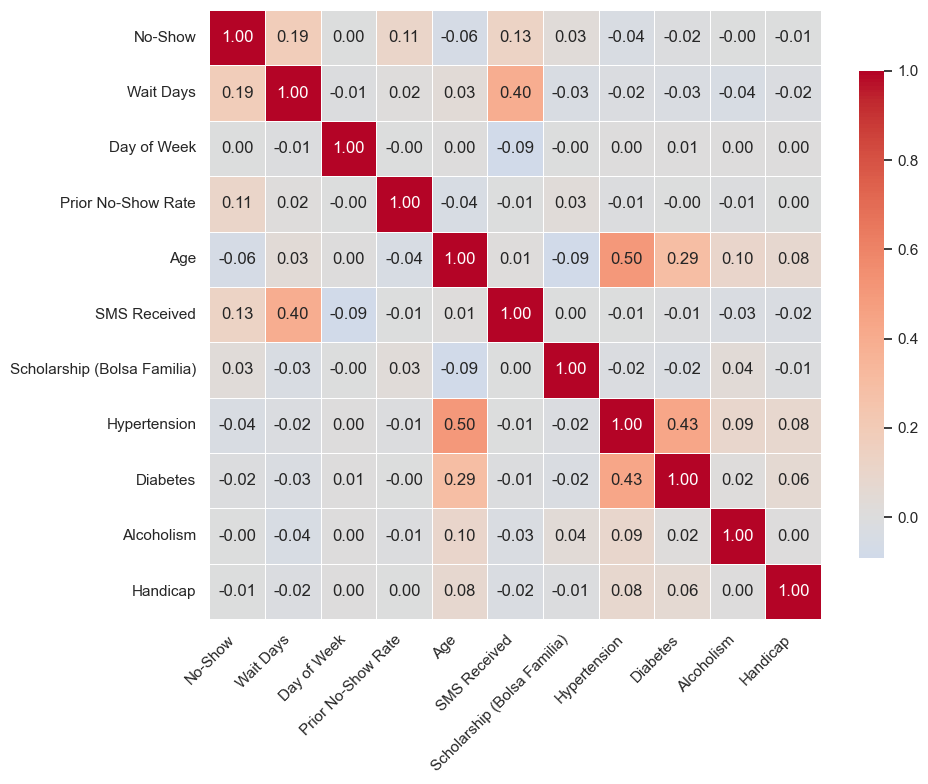

In [32]:
# Figure 3 — correlation heatmap with display labels
heatmap_cols = [
    "no_show", "wait_days", "appt_day_of_week", "prior_noshow_rate",
    "Age", "SMS_received", "Scholarship",
    "Hipertension", "Diabetes", "Alcoholism", "Handcap",
]
display_labels = [
    "No-Show", "Wait Days", "Day of Week", "Prior No-Show Rate",
    "Age", "SMS Received", "Scholarship (Bolsa Familia)",
    "Hypertension", "Diabetes", "Alcoholism", "Handicap",
]
corr_matrix = df[heatmap_cols].corr()
corr_matrix.columns = display_labels
corr_matrix.index = display_labels

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("figure3.png", dpi=150, bbox_inches="tight")
plt.show()


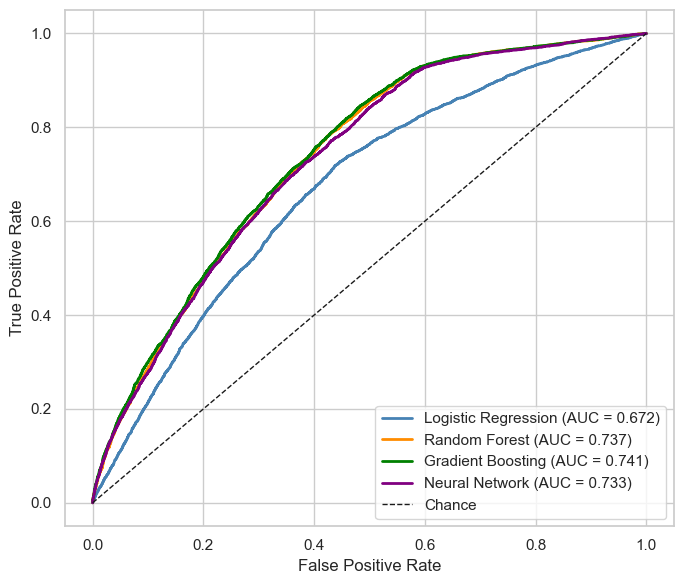

In [33]:
# refit LR with class_weight balanced for fair ROC comparison
lr_roc = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_roc.fit(X_train_s, y_train)
lr_prob_roc = lr_roc.predict_proba(X_test_s)[:, 1]

# Figure 4 — ROC curves for all four models
fig, ax = plt.subplots(figsize=(7, 6))
for prob, label, color in [
    (lr_prob_roc, "Logistic Regression", "steelblue"),
    (rf_prob,     "Random Forest",       "darkorange"),
    (gb_prob,     "Gradient Boosting",   "green"),
    (nn_prob_t,   "Neural Network",      "purple"),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{label} (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figure4.png", dpi=150, bbox_inches="tight")
plt.show()


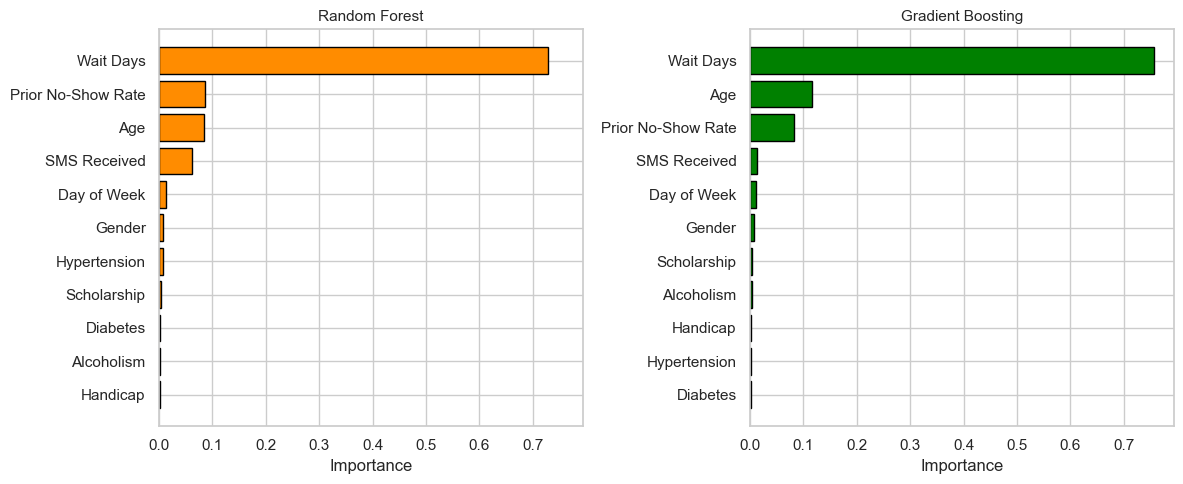

In [34]:
# Figure 5 — feature importance with display labels, matching ROC colors
display_label_map = {
    "wait_days": "Wait Days",
    "appt_day_of_week": "Day of Week",
    "prior_noshow_rate": "Prior No-Show Rate",
    "Age": "Age",
    "Gender": "Gender",
    "SMS_received": "SMS Received",
    "Scholarship": "Scholarship",
    "Hipertension": "Hypertension",
    "Diabetes": "Diabetes",
    "Alcoholism": "Alcoholism",
    "Handcap": "Handicap",
}

rf_imp = (pd.DataFrame({"feature": feature_cols, "importance": rf.feature_importances_})
            .sort_values("importance", ascending=True))
gb_imp = (pd.DataFrame({"feature": feature_cols, "importance": gb.feature_importances_})
            .sort_values("importance", ascending=True))

rf_imp["feature"] = rf_imp["feature"].map(display_label_map)
gb_imp["feature"] = gb_imp["feature"].map(display_label_map)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
axes[0].barh(rf_imp["feature"], rf_imp["importance"], color="darkorange", edgecolor="black")
axes[0].set_xlabel("Importance")
axes[0].set_title("Random Forest", fontsize=11)

axes[1].barh(gb_imp["feature"], gb_imp["importance"], color="green", edgecolor="black")
axes[1].set_xlabel("Importance")
axes[1].set_title("Gradient Boosting", fontsize=11)

plt.tight_layout()
plt.savefig("figure5.png", dpi=150, bbox_inches="tight")
plt.show()


In [35]:
# Table 1 — final model comparison
print("\nTable 1. ROC-AUC scores for all four models on the held-out test set,")
print("with five-fold cross-validation mean and standard deviation where applicable.\n")

summary = pd.DataFrame([
    {"Model": "Logistic Regression", "ROC-AUC (test)": 0.6677, "CV Mean": 0.6705, "CV Std": 0.0047},
    {"Model": "Random Forest",       "ROC-AUC (test)": round(rf_auc, 4), "CV Mean": round(rf_cv.mean(), 4), "CV Std": round(rf_cv.std(), 4)},
    {"Model": "Gradient Boosting",   "ROC-AUC (test)": round(gb_auc, 4), "CV Mean": round(gb_cv.mean(), 4), "CV Std": round(gb_cv.std(), 4)},
    {"Model": "Neural Network",      "ROC-AUC (test)": round(nn_auc, 4), "CV Mean": round(nn_cv_mean, 4), "CV Std": round(nn_cv_std, 4)},
])
print(summary.to_string(index=False))



Table 1. ROC-AUC scores for all four models on the held-out test set,
with five-fold cross-validation mean and standard deviation where applicable.

              Model  ROC-AUC (test)  CV Mean  CV Std
Logistic Regression          0.6677   0.6705  0.0047
      Random Forest          0.7370   0.7408  0.0054
  Gradient Boosting          0.7412   0.7434  0.0048
     Neural Network          0.7328   0.7383  0.0043
